In [3]:
library(ggplot2)
library(readr)
library(corrplot)
library(FactoMineR)

In [4]:
europe <- read_table("C:\\Users\\Julien ANTOGNELLI\\Documents\\ESGI\\Maths\\MathsForR\\data\\Donnees Europe.dat", 
    skip = 1,
    col_names =c (
        "pays", "benev", "chom", "depsoc", "devel", "heur", "pib",
        "satfam", "satlogt", "satnvie", "spauvr", "ssabri", "vief", "vieh")
)


── Column specification ────────────────────────────────────────────────────────
cols(
  pays = col_character(),
  benev = col_double(),
  chom = col_double(),
  depsoc = col_double(),
  devel = col_double(),
  heur = col_double(),
  pib = col_double(),
  satfam = col_double(),
  satlogt = col_double(),
  satnvie = col_double(),
  spauvr = col_double(),
  ssabri = col_double(),
  vief = col_double(),
  vieh = col_double()
)



# Introduction au jeu de données

In [5]:
head(europe)

pays,benev,chom,depsoc,devel,heur,pib,satfam,satlogt,satnvie,spauvr,ssabri,vief,vieh
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
at,60,4.7,29.1,0.944,20,128.8,8.2,39,32,900,3,82,77
be,37,8.1,29.3,0.945,40,112.3,7.9,55,35,822,5,82,77
cy,23,4.6,17.8,0.903,24,93.2,7.9,49,24,658,4,82,77
cz,33,7.7,19.6,0.885,16,79.4,7.5,37,14,212,6,79,73
de,52,9.1,29.5,0.932,24,113.6,8.1,52,31,856,2,82,76
dk,49,4.9,30.7,0.943,49,126.7,8.7,55,55,1106,1,80,76


## Graphes de couples de variables

### Couple `chom`et `depsoc`

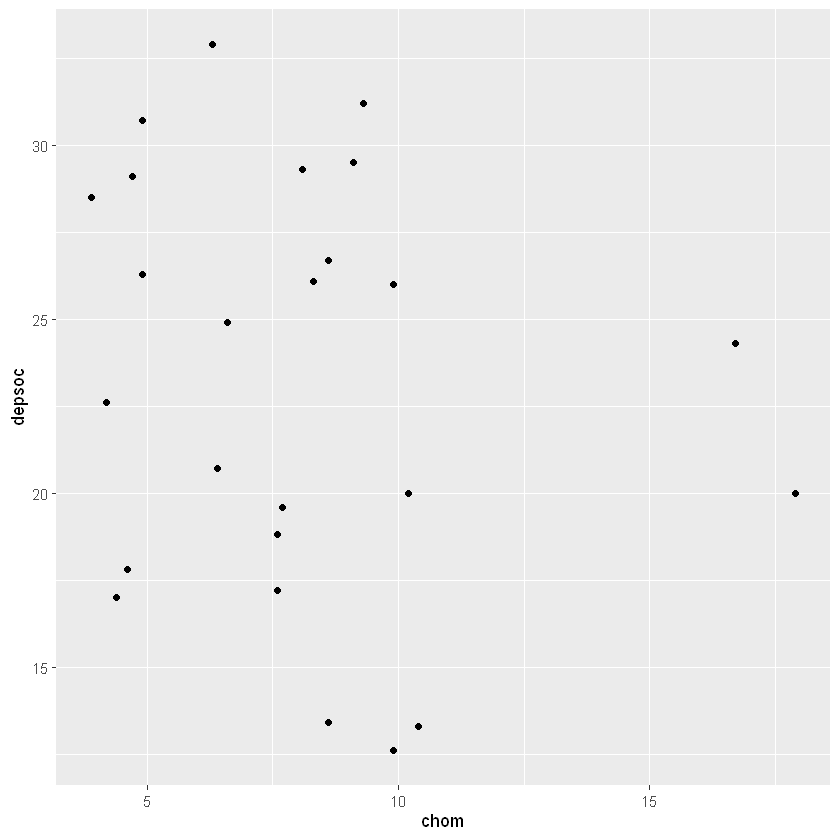

In [6]:
ggplot(europe, aes(x = chom, y = depsoc)) +
  geom_point() +
  labs(x = "chom",
       y = "depsoc")


### Couple `PIB`et `devel`

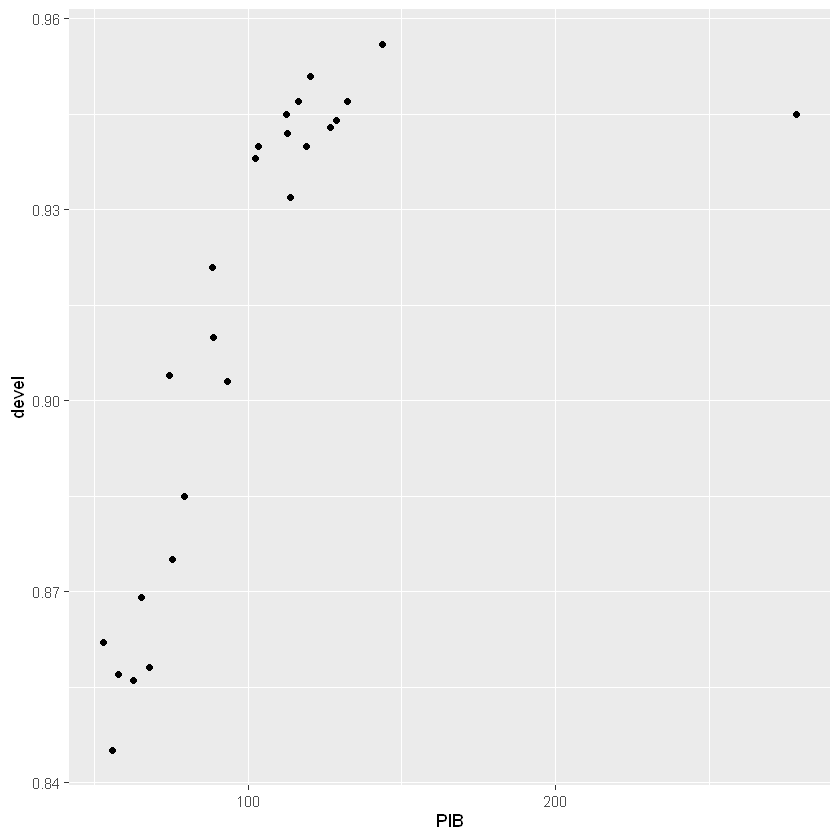

In [7]:
ggplot(europe, aes(x = pib, y = devel)) +
  geom_point() +
  labs(x = "PIB",
       y = "devel")

### Couple `benev`et `pvapr`
/!\ `pvapr`n'existe pas dans le fichier

**Interprétation**

- (chom, depsoc) -> nuage dispersé, pas de tendance
- (PIB, devel) -> tendance croissante nette, mais un point isolé avec un très fort PIB

## Matrice des corrélations des variables

In [8]:
# enlève la colonne pays pour ne garder que les variables numériques
Europe_num <- europe[, -1]   

In [9]:
cor_mat <- round(cor(Europe_num, method = "pearson"), 2)
cor_mat
write.csv(cor_mat, file = "./graphs_&_tables/corr_matrix.csv", row.names = TRUE)

,benev,chom,depsoc,devel,heur,pib,satfam,satlogt,satnvie,spauvr,ssabri,vief,vieh
benev,1.00,-0.41,0.58,0.62,0.52,0.56,0.39,0.52,0.58,0.67,-0.56,0.40,0.43
chom,-0.41,1.00,-0.19,-0.56,-0.57,-0.55,-0.40,-0.54,-0.61,-0.63,0.40,-0.35,-0.46
depsoc,0.58,-0.19,1.00,0.70,0.49,0.36,0.47,0.39,0.49,0.61,-0.50,0.59,0.66
devel,0.62,-0.56,0.70,1.00,0.76,0.69,0.67,0.61,0.74,0.88,-0.55,0.86,0.84
heur,0.52,-0.57,0.49,0.76,1.00,0.64,0.61,0.80,0.88,0.81,-0.52,0.51,0.63
pib,0.56,-0.55,0.36,0.69,0.64,1.00,0.54,0.70,0.80,0.87,-0.48,0.52,0.52
satfam,0.39,-0.40,0.47,0.67,0.61,0.54,1.00,0.68,0.77,0.72,-0.64,0.60,0.77
satlogt,0.52,-0.54,0.39,0.61,0.80,0.70,0.68,1.00,0.83,0.79,-0.59,0.49,0.65
satnvie,0.58,-0.61,0.49,0.74,0.88,0.80,0.77,0.83,1.00,0.89,-0.63,0.52,0.68
spauvr,0.67,-0.63,0.61,0.88,0.81,0.87,0.72,0.79,0.89,1.00,-0.54,0.70,0.76


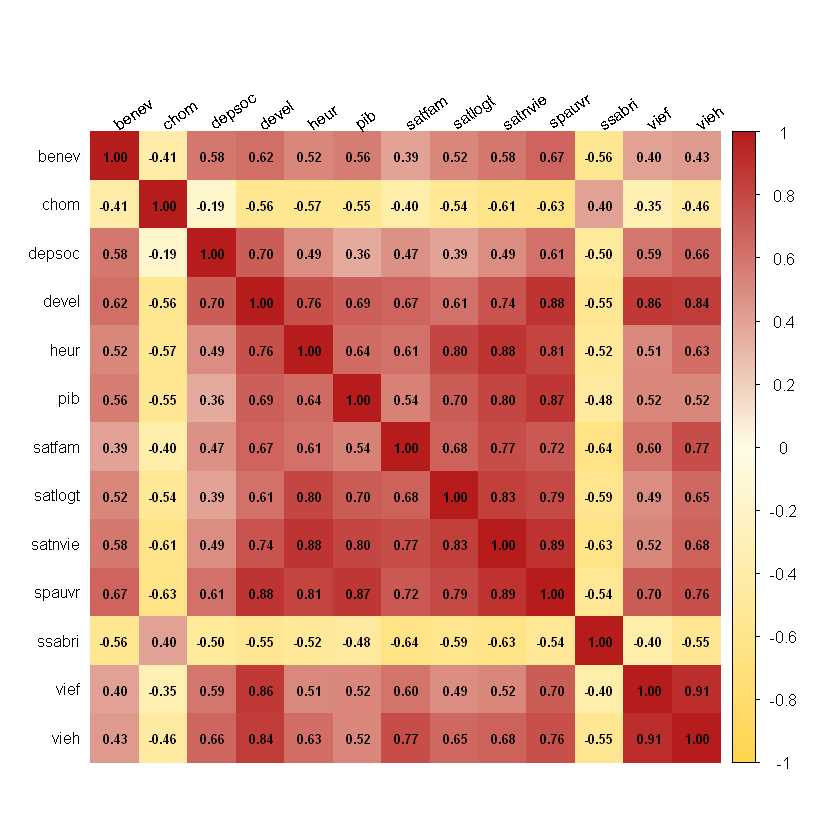

In [10]:
corrplot(cor_mat,
         method = "color",
         type = "full",
         diag = TRUE,
         col = colorRampPalette(c("#FFD54F", "#FFFDE7", "#B71C1C"))(200),
         tl.col = "black",
         tl.cex = 0.8,
         tl.srt = 35,
         addCoef.col = "black",
         number.cex = 0.65,
         mar = c(1, 1, 2, 1)
         )

**Interprétation**

- Le plus corrélé -> (vief, vieh) avec un coefficient de corrélation de 0,91 

- Le moins corrélé -> (chom, depsoc) avec -0,19

- Le plus opposé -> (satfam, ssabri) avec -0,64 

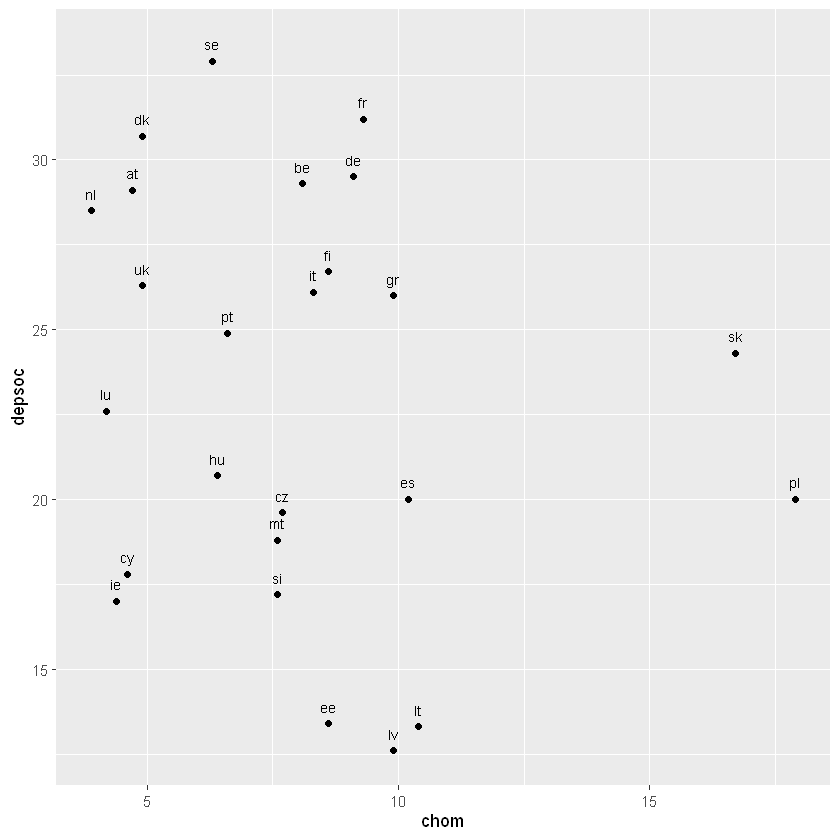

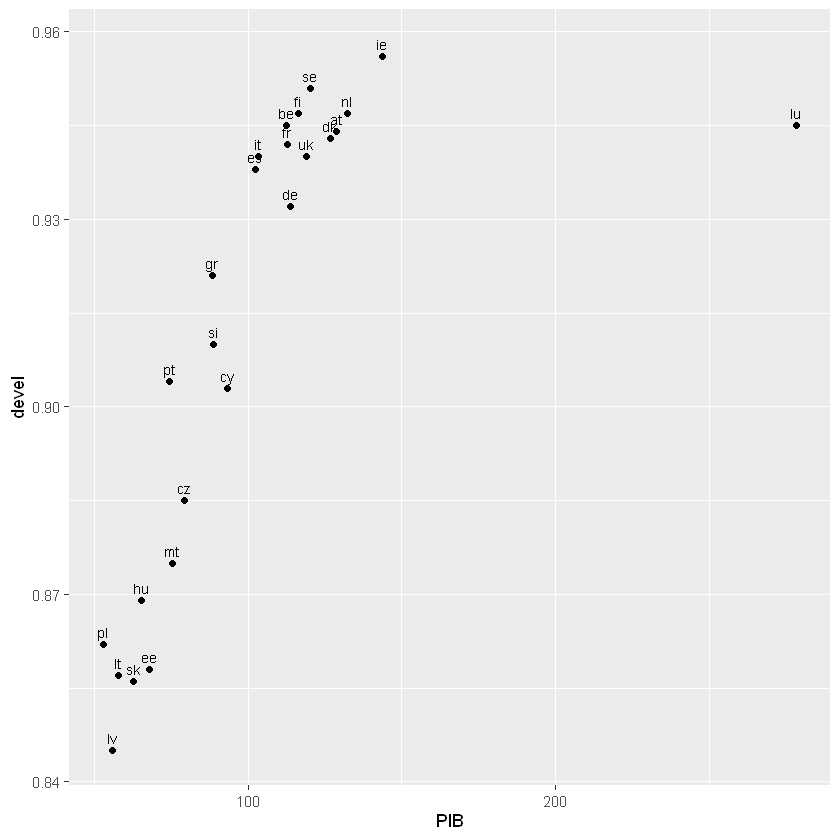

In [23]:
rownames(europe) <- europe[, 1]

# Graphe avec labels pays pour identifier visuellement
ggplot(europe, aes(x = chom, y = depsoc, label = rownames(europe))) +
  geom_point() +
  geom_text(nudge_y = 0.5, size = 3) +
  labs(x = "chom", y = "depsoc")

# Idem pour PIB / devel
ggplot(europe, aes(x = pib, y = devel, label = rownames(europe))) +
  geom_point() +
  geom_text(nudge_y = 0.002, size = 3) +
  labs(x = "PIB", y = "devel")

**Détection d'individus anormaux**

Couple `(chom, depsoc)` -> 
- ee, lv et lt se détachent nettement en bas du graphe
- sk et pl sont isolés à droite 

**donc** : ces outliers tirent dans des directions contradictiones et s'annulent mutuellement ce qui fait chuter la corrélation à -0.19

Couple `(PIB, devel)`->
- lu est complètement isolé à droite
- ie en haut à gauche a l'IDH le plus élevé avec un PIB dans la moyenne
- lv en bas à gauche: PIB et IDH tous les deux faibles

**donc** lu déforme l'axe horizontal et affaiblit le coefficient, car son PIB n'est pas proportionnellement reflété dans son IDH

# Première ACP

### Pré-traitement du df avant manipulations

In [12]:
# conversion requise par FactoMineR
europe <- as.data.frame(europe)

# Mettre la 1re colonne (pays) en noms de lignes
rownames(europe) <- europe[, 1]

# Supprimer la 1re colonne du tableau de données
europe_num <- europe[, -1]

## Centrer et réduire les données

In [13]:
# scale.unit = TRUE centre et réduit les données(ACP normée)
# ncp = 4 indique que l'on souhaite conserver les 4 premières composantes principales
res.pca <- PCA(europe_num, scale.unit = TRUE, ncp = 4, graph = FALSE)

## Variances des composantes principales

In [14]:
# $eig renvoie les valeurs propres, les pourcentages de variance expliquée et les pourcentages de variance cumulée
variances_cp <- data.frame(
  Axe = paste0("Dim.", 1:4),
  Variance = round(res.pca$eig[1:4, 1], 2)
)

variances_cp
write.csv(variances_cp, file = "./graphs_&_tables/variances_cp.csv", row.names = FALSE)

,Axe,Variance
,<chr>,<dbl>
comp 1,Dim.1,8.39
comp 2,Dim.2,1.22
comp 3,Dim.3,0.84
comp 4,Dim.4,0.73


## Tableau de corrélation des variables

In [15]:
corr_variables <- round(res.pca$var$cor[, 1:4], 2)
corr_variables
write.csv(corr_variables, file = "./graphs_&_tables/corr_variables.csv", row.names = TRUE)

,Dim.1,Dim.2,Dim.3,Dim.4
benev,0.69,-0.04,-0.60,0.25
chom,-0.64,0.43,-0.17,-0.25
depsoc,0.67,0.52,-0.35,0.08
devel,0.91,0.23,0.07,0.21
heur,0.85,-0.22,0.05,0.00
pib,0.80,-0.30,0.02,0.21
satfam,0.80,0.08,0.16,-0.44
satlogt,0.83,-0.30,0.06,-0.20
satnvie,0.91,-0.27,0.02,-0.11
spauvr,0.96,-0.08,0.04,0.17


Coordonées des variables => corrélations variable / composante

Toutes les variables ont une forte corrélation avec Dim1 -> effet de taille

## Coordonées des individus sur les axes

In [16]:
coord_individus <- round(res.pca$ind$coord[, 1:4], 2)
coord_individus
write.csv(coord_individus, file = "./graphs_&_tables/coord_individus.csv", row.names = TRUE)

,Dim.1,Dim.2,Dim.3,Dim.4
at,2.20,0.57,-1.14,0.71
be,2.05,0.43,-0.04,0.10
cy,0.26,-0.37,1.21,-0.48
cz,-2.00,-0.34,-0.43,-0.18
de,1.82,0.77,-1.20,-0.20
dk,3.82,-0.91,-0.88,-0.77
ee,-4.16,-1.15,-0.71,0.86
es,0.30,1.29,1.52,-0.68
fi,1.71,0.78,-0.86,-0.01
fr,0.59,1.85,0.55,2.05


## Contribution des individus aux axes 

In [17]:
contrib_individus <- round(res.pca$ind$contrib[, 1:4], 2)
contrib_individus
write.csv(contrib_individus, file = "./graphs_&_tables/contrib_individus.csv", row.names = TRUE)

,Dim.1,Dim.2,Dim.3,Dim.4
at,2.31,1.08,6.16,2.73
be,2.01,0.61,0.01,0.06
cy,0.03,0.45,6.98,1.24
cz,1.90,0.38,0.90,0.17
de,1.58,1.94,6.84,0.22
dk,6.97,2.72,3.65,3.21
ee,8.26,4.33,2.43,4.03
es,0.04,5.44,10.92,2.54
fi,1.40,2.01,3.54,0.00
fr,0.17,11.21,1.44,23.05


## Faire une représentation graphique des valeurs propres

In [18]:
png("./graphs_&_tables/valeurs_propres.png", width = 800, height = 600, res = 120)

# récupérer les valeurs propres
vp <- res.pca$eig[, 1]

plot(1:length(vp), vp, type = "b", pch = 19,
     xlab = "Axes principaux",
     ylab = "Valeurs propres")

# ligne du critère de Kaiser
abline(h = 1, col = "red", lty = 2)

legend("topright",
       legend = expression("Critère de Kaiser (" * lambda == 1 * ")"),
       col = "red",
       lty = 2,
       lwd = 1,
       bty = "n")

dev.off()

pdf 
  2

Selon la règle de Kaiser (valeur propre > 1, ligne rouge) :

2 composantes principales sont à retenir: l'axe 1 (~8.5) et l'axe 2 (~1.2) sont au-dessus du seuil, l'axe 3 passe déjà en dessous.

## Pourcentage d'inertie totale expliquée par le sous-espace principal correspondant

In [19]:
# Extraction des lignes où la valeur propre est > 1, puis arrondi à 2 décimales
res_filtre <- round(res.pca$eig[res.pca$eig[, 1] > 1, ], 2)

# Affichage du résultat
res_filtre

,eigenvalue,percentage of variance,cumulative percentage of variance
comp 1,8.39,64.55,64.55
comp 2,1.22,9.36,73.91


2 axes sont retenus, le 1 et 2 et expliquent à eux seuls 73.91% de l'inertie

## Tracer le cercle de corrélation des variables

pdf 
  2

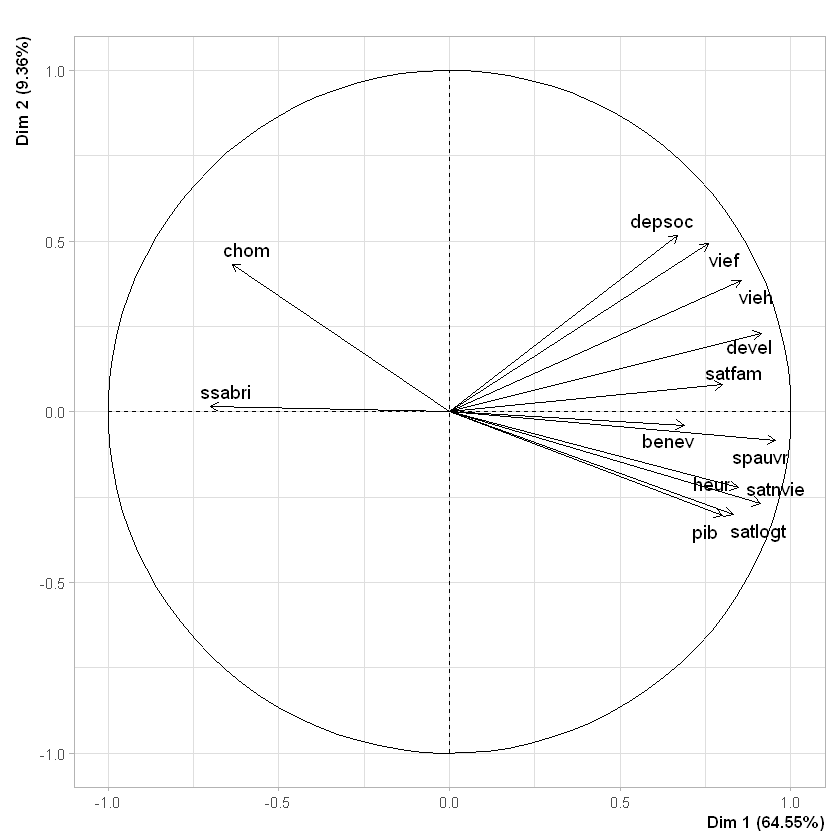

In [20]:
png("./graphs_&_tables/cercle_correlation.png", width = 800, height = 800, res = 120)

# choix = "var" indique que l'on souhaite afficher les variables
plot(res.pca, choix = "var", axes = c(1, 2), title = " ")

dev.off()

# Affichage
plot(res.pca, choix = "var", axes = c(1, 2), title="")

In [21]:
corr_vars <- round(res.pca$var$coord[, 1:2], 2)

axe_dominant <- apply(corr_vars, 1, function(x) {
  if (abs(x[1]) > abs(x[2])) {
    paste0("Dim 1 (", ifelse(x[1] >= 0, "+", "-"), ")")
  } else if (abs(x[2]) > abs(x[1])) {
    paste0("Dim 2 (", ifelse(x[2] >= 0, "+", "-"), ")")
  } else {
    "Dim 1 et 2"
  }
})

tab_axes <- data.frame(
  Variable = rownames(corr_vars),
  `Axe dominant` = axe_dominant,
  `r (Dim 1)` = corr_vars[, 1],
  `r (Dim 2)` = corr_vars[, 2],
  row.names = NULL,
  check.names = FALSE
)

tab_axes
write.csv(tab_axes, file = "./graphs_&_tables/axes_variables.csv", row.names = FALSE)

Variable,Axe dominant,r (Dim 1),r (Dim 2)
<chr>,<chr>,<dbl>,<dbl>
benev,Dim 1 (+),0.69,-0.04
chom,Dim 1 (-),-0.64,0.43
depsoc,Dim 1 (+),0.67,0.52
devel,Dim 1 (+),0.91,0.23
heur,Dim 1 (+),0.85,-0.22
pib,Dim 1 (+),0.80,-0.30
satfam,Dim 1 (+),0.80,0.08
satlogt,Dim 1 (+),0.83,-0.30
satnvie,Dim 1 (+),0.91,-0.27


Toutes les variables sont dominées par Dim1, aucune n'est exclusive à Dim2 ce qui confirme que l'axe 2 est secondaire et difficile à interpréter seul 

**effet de taille important**